In [1]:
# --- IMPORTS ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import timm  # PyTorch Image Models (Standard for ViT/DiET)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import time
import copy
import os

# --- CONFIGURATION ---
BATCH_SIZE = 32          # ViTs are memory hungry, reduce if OOM (Out of Memory)
NUM_EPOCHS = 30          # Transformers need more epochs than CNNs
LEARNING_RATE = 5e-5     # Lower LR is crucial for Transformers
WEIGHT_DECAY = 0.05      # Higher weight decay helps regularization (AdamW)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- 1. DATASET CLASS ---
class MemoryCachedDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        self.samples = self.data['samples']
        self.classes = self.data['classes']
        self.class_to_idx = self.data['class_to_idx']

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

# Load Data
try:
    train_dataset = MemoryCachedDataset("train_cache.pt")
    val_dataset = MemoryCachedDataset("val_cache.pt")
    test_dataset = MemoryCachedDataset("test_cache.pt")
    
    class_names = train_dataset.classes
    num_classes = len(class_names)
    print(f"Classes ({num_classes}): {class_names}")

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
except FileNotFoundError:
    print("Error: Cache files not found. Please run the caching script first.")

# --- 2. DEFINE DiET-SMALL MODEL ---
def initialize_diet_small(num_classes):
    """
    Loads a pure Vision Transformer (ViT-Small)
    Architecture:
    - Patch Size: 16x16
    - Embed Dim: 384 (Small)
    - Heads: 6
    - Layers: 12
    """
    print("Initializing DiET-Small (vit_small_patch16_224)...")
    
    # Load pre-trained weights (trained on ImageNet)
    model = timm.create_model(
        'vit_small_patch16_224', 
        pretrained=True, 
        num_classes=num_classes,
        drop_rate=0.1,        # Dropout probability
        attn_drop_rate=0.1    # Attention dropout
    )
    
    return model.to(DEVICE)

model = initialize_diet_small(num_classes)

# --- 3. OPTIMIZER & LOSS ---
# ViTs usually train better with AdamW (Adam with Weight Decay)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Cosine Annealing Scheduler (Standard for Transformers)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# --- 4. TRAINING FUNCTION ---
def train_model(model, train_loader, val_loader, num_epochs=10, checkpoint_path="best_diet_small.pth"):
    since = time.time()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print(f"Training started... Checkpoints: {checkpoint_path}")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                # Step scheduler only after training epoch
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Checkpointing
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), checkpoint_path)
                    print(f"  --> New Best Model! Saved. (Acc: {best_acc:.4f})")

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# --- 5. RUN TRAINING ---
trained_model, history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs=NUM_EPOCHS, 
    checkpoint_path="best_diet_small.pth"
)


c:\Users\sreeh\miniconda3\envs\your_env_name\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Classes (6): ['Cysts_Structural', 'Dysarthia', 'Laryngitis', 'Vox senilis', 'parkinson', 'spasmodische_dysphonie']
Initializing DiET-Small (vit_small_patch16_224)...
Training started... Checkpoints: best_diet_small.pth

Epoch 1/30
----------
train Loss: 0.6316 Acc: 0.7598
val Loss: 0.5373 Acc: 0.8251
  --> New Best Model! Saved. (Acc: 0.8251)

Epoch 2/30
----------
train Loss: 0.2641 Acc: 0.9017
val Loss: 0.6821 Acc: 0.7578

Epoch 3/30
----------
train Loss: 0.1382 Acc: 0.9520
val Loss: 0.5575 Acc: 0.8296
  --> New Best Model! Saved. (Acc: 0.8296)

Epoch 4/30
----------
train Loss: 0.0714 Acc: 0.9763
val Loss: 0.4213 Acc: 0.8924
  --> New Best Model! Saved. (Acc: 0.8924)

Epoch 5/30
----------
train Loss: 0.0682 Acc: 0.9770
val Loss: 0.3873 Acc: 0.8879

Epoch 6/30
----------
train Loss: 0.0266 Acc: 0.9932
val Loss: 0.5108 Acc: 0.8430

Epoch 7/30
----------
train Loss: 0.0317 Acc: 0.9884
val Loss: 0.4684 Acc: 0.8655

Epoch 8/30
----------
train Loss: 0.0128 Acc: 0.995

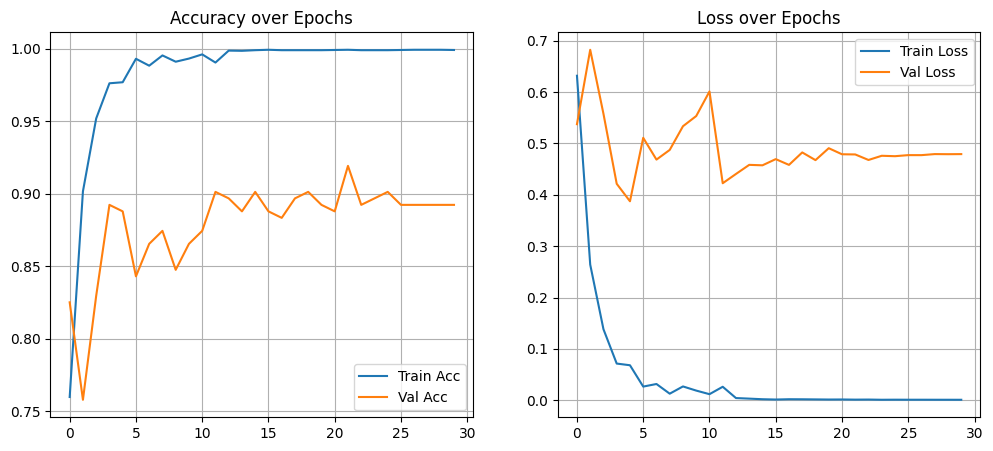


--- Evaluating on Test Set ---

Classification Report:
                        precision    recall  f1-score   support

      Cysts_Structural       1.00      0.86      0.93        22
             Dysarthia       1.00      1.00      1.00        42
            Laryngitis       0.77      0.88      0.82        42
           Vox senilis       0.96      0.92      0.94        50
             parkinson       0.94      1.00      0.97        50
spasmodische_dysphonie       0.75      0.60      0.67        20

              accuracy                           0.91       226
             macro avg       0.90      0.88      0.89       226
          weighted avg       0.91      0.91      0.91       226



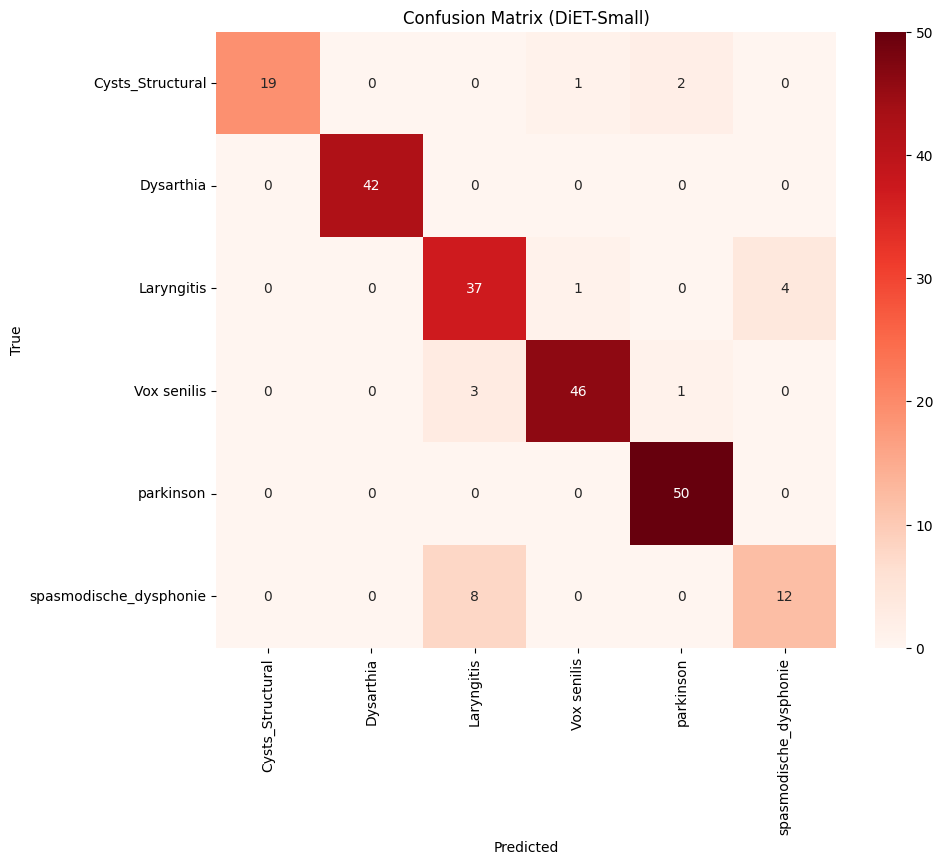

In [2]:

# --- 6. PLOT RESULTS ---
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.show()

# --- 7. EVALUATION ---
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

print("\n--- Evaluating on Test Set ---")
y_true, y_pred = evaluate_model(trained_model, test_loader)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (DiET-Small)')
plt.show()